## 1. Problem Definition

**What problem are we solving?**
Recruiters often receive hundreds of CVs for a single job opening. Manually reading
and comparing every CV against the job description is slow, tedious, and prone to
inconsistency between reviewers. This project builds an AI-assisted CV screening
system that automatically compares a candidate's CV/skills against a job description
and produces a match score and a screening recommendation, helping recruiters
prioritize which applications to review first.

**Why is this problem important?**
- Saves recruiter time during the initial screening stage.
- Provides a consistent, repeatable first-pass filter across all applicants.
- Helps surface strong candidates who might otherwise be missed in a large pile of CVs.

**Who would use the system?**
Recruiters, HR teams, and hiring managers doing first-pass screening of job
applications before human interviews.

**What will the AI predict?**
Given a candidate's CV/skills/experience and a job description, the system predicts
a screening recommendation category:
- **Interview** – strong match, recommend moving forward
- **Manual Review** – partial match, needs human judgement
- **Not Qualified** – weak match on required skills/experience

As a stretch goal, the system may also predict a continuous **match score (0–100)**
to give a finer-grained sense of fit alongside the category.

**Important Ethical Consideration**
This system is an *assistive* screening tool, not an automatic hiring decision-maker.
It is designed to help recruiters prioritize their review queue — it does not reject
candidates on its own. A candidate should never be eliminated from consideration
solely because this model produced a low score; a human reviewer should always have
the final say, especially for borderline ("Manual Review") cases.

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai_cv_candidate_matching_10000.csv")

column, row = df.shape
print("Column: ", column)
print("Row: ", row)
df.head()

Column:  10000
Row:  28


,application_id,candidate_id,resume_summary,candidate_skills,experience_years,education,certification,projects_count,candidate_location,work_authorization,...,minimum_experience_years,job_location,salary_min_usd,salary_max_usd,required_skill_coverage,preferred_skill_coverage,match_score,screening_recommendation,label_reason,data_split
0,APP00001,CAND00001,Synthetic candidate with 0 years of experience...,"Bash, Ethical Hacking, Incident Response, Python",0,B.Sc Computer Science,AWS Certified Data Analytics,1,Remote - US,Authorized,...,2,"Boston, MA",70000,125000,0.25,0.0,23,Not Qualified,Manual review needed; missing required skills:...,train
1,APP00002,CAND00002,Synthetic candidate with 5 years of experience...,"Computer Vision, Python, SIEM",5,B.Sc Information Technology,CEH,5,"Austin, TX",Requires sponsorship,...,4,"Denver, CO",80000,140000,0.33,0.5,58,Manual Review,Manual review needed; missing required skills:...,train
2,APP00003,CAND00003,Synthetic candidate with 0 years of experience...,"C++, Communication, Deep Learning, Pandas, SQL...",0,M.Sc Data Science,AWS Certified Data Analytics,2,"Atlanta, GA",Authorized,...,2,"Boston, MA",70000,125000,0.50,0.5,44,Not Qualified,Manual review needed; missing required skills:...,train
3,APP00004,CAND00004,Synthetic candidate with 6 years of experience...,"AWS, Airflow, Docker, ETL, Python, SQL, Terraform",6,M.Sc Data Engineering,NaN,3,"Chicago, IL",Authorized,...,4,"Atlanta, GA",87000,148000,1.00,1.0,93,Interview,Meets required-skill threshold with relevant e...,train
4,APP00005,CAND00005,Synthetic candidate with 1 years of experience...,"CI/CD, Communication, Linux",1,B.Eng Software Engineering,NaN,1,Remote - US,Authorized,...,2,"Denver, CO",75000,132000,0.50,0.0,42,Not Qualified,Manual review needed; missing required skills:...,train


In [3]:
df.columns.tolist()

['application_id',
 'candidate_id',
 'resume_summary',
 'candidate_skills',
 'experience_years',
 'education',
 'certification',
 'projects_count',
 'candidate_location',
 'work_authorization',
 'salary_expectation_usd',
 'application_date',
 'job_id',
 'job_title',
 'job_role',
 'job_description',
 'required_skills',
 'preferred_skills',
 'minimum_experience_years',
 'job_location',
 'salary_min_usd',
 'salary_max_usd',
 'required_skill_coverage',
 'preferred_skill_coverage',
 'match_score',
 'screening_recommendation',
 'label_reason',
 'data_split']

# DATA EXPLORATION

In [4]:
df.info()
print()
print("CHECKING FOR MISSING VALUES")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   application_id            10000 non-null  str    
 1   candidate_id              10000 non-null  str    
 2   resume_summary            10000 non-null  str    
 3   candidate_skills          10000 non-null  str    
 4   experience_years          10000 non-null  int64  
 5   education                 10000 non-null  str    
 6   certification             5152 non-null   str    
 7   projects_count            10000 non-null  int64  
 8   candidate_location        10000 non-null  str    
 9   work_authorization        10000 non-null  str    
 10  salary_expectation_usd    10000 non-null  int64  
 11  application_date          10000 non-null  str    
 12  job_id                    10000 non-null  str    
 13  job_title                 10000 non-null  str    
 14  job_role          

The 4,848 missing values above are most certainly not missing values, it just means the cadidate has no certification. I fixed that in Preprocessing by filling it with "None"

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df['screening_recommendation'].value_counts()

screening_recommendation
Interview        4133
Not Qualified    3763
Manual Review    2104
Name: count, dtype: int64

In [7]:
df['screening_recommendation'].value_counts(normalize=True) * 100

screening_recommendation
Interview        41.33
Not Qualified    37.63
Manual Review    21.04
Name: proportion, dtype: float64

Note the split above, 41% Interview, 38% Not Qualified, 21% Manual Review. It is not perfectly balanced but also not extreme either.

In [8]:
df['data_split'].value_counts()

data_split
train         7000
test          2000
validation    1000
Name: count, dtype: int64

This confirms the dataset I have chosen came pre-split: 7,000 train / 2,000 test / 1,000 validation. I will honor this split rather than re-splitting randomly, since whoever built the dataset intended it this way.

In [9]:
print("NUMERIC FEATURES SUMMARY")
print()
df[['experience_years','projects_count','salary_expectation_usd',
    'minimum_experience_years','salary_min_usd','salary_max_usd']].describe()

NUMERIC FEATURES SUMMARY



,experience_years,projects_count,salary_expectation_usd,minimum_experience_years,salary_min_usd,salary_max_usd
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000
mean,3.663800,4.605900,111538.950000,2.846100,76661.50000,135534.60000
std,2.765888,2.703982,29621.581688,0.968767,7197.49249,11006.99406
min,0.000000,0.000000,53500.000000,2.000000,65000.00000,120000.00000
25%,1.000000,3.000000,86500.000000,2.000000,70000.00000,125000.00000
50%,3.000000,4.000000,111000.000000,2.000000,75000.00000,132000.00000
75%,6.000000,6.000000,135000.000000,4.000000,80000.00000,145000.00000
max,13.000000,12.000000,192000.000000,5.000000,92000.00000,163000.00000


In [10]:
print("QUICK LOOK AT THE TEXTFIELDS FOR ONE ROW")
print()
row = df.iloc[0]
print("CANDIDATE SKILLS:", row['candidate_skills'])
print()
print("REQUIRED SKILLS:", row['required_skills'])
print()
print("PREFERRED SKILLS:", row['preferred_skills'])
print()
print("LABEL:", row['screening_recommendation'], "| reason:", row['label_reason'])

QUICK LOOK AT THE TEXTFIELDS FOR ONE ROW

CANDIDATE SKILLS: Bash, Ethical Hacking, Incident Response, Python

REQUIRED SKILLS: SQL, Python, Statistics, Machine Learning

PREFERRED SKILLS: Pandas, scikit-learn

LABEL: Not Qualified | reason: Manual review needed; missing required skills: SQL, Statistics, Machine Learning.


In [11]:
df.experience_years.unique()

array([ 0,  5,  6,  1,  7,  3,  2,  9,  4, 10,  8, 11, 12, 13])

In [12]:
df.salary_expectation_usd.unique()

array([118000,  97000, 117000, 161500, 132500, 154000, 111500, 105500,
        82000,  86000, 121500,  94500,  80000, 121000, 139000, 158500,
       123500, 119000, 105000,  88000,  80500, 108500, 174000, 127500,
       135000,  83000,  83500, 136500, 142000, 122500, 123000, 116500,
       110000, 129500, 150500, 101500,  67000,  67500, 117500,  87500,
        76500, 115000, 167000, 136000, 160500, 157000, 112000,  71500,
       124000,  65500,  64500,  73000, 163000,  85500,  89500,  73500,
       120000, 145500, 138000, 106500, 100500, 140500, 145000, 160000,
       113000, 126000, 169500, 130000,  79000, 102500, 133000, 130500,
       108000,  76000, 112500,  66500,  61500, 122000,  77500, 142500,
       158000, 143000,  90000,  63000,  99000, 101000, 137000, 141500,
       125000, 114000,  96500, 139500,  87000, 147000, 107500, 151500,
       107000, 129000,  77000, 179500,  98000, 109500,  86500, 104500,
        96000, 186000,  99500, 144000, 116000,  89000,  93000, 153500,
      

# DATA PREPROCESSING

I handled the missing values, text cleaning and preparing the skill list for comparison

In [13]:
df['certification'] = df['certification'].fillna('None')
# Since missing here means "no certificate", not "unknown", it's best I fill than drop
print(df.certification.isna().sum())
print()
df.certification

0



0        AWS Certified Data Analytics
1                                 CEH
2        AWS Certified Data Analytics
3                                None
4                                None
                    ...              
9995    AWS Certified DevOps Engineer
9996                             None
9997                             None
9998                             None
9999                             None
Name: certification, Length: 10000, dtype: str

A text cleaning function is needed to clean free_text fields like resume_salary and job_description before I TF-IDF them.

In [14]:
def clean_text(text):
    text = str(text).lower()                      # lowercase
    text = re.sub(r'[^a-z0-9\s,]', ' ', text)     # remove punctuation except commas (commas help split skills)
    text = re.sub(r'\s+', ' ', text).strip()      # collapse extra whitespace
    return text

df['resume_summary_clean'] = df['resume_summary'].apply(clean_text)
df['job_description_clean'] = df['job_description'].apply(clean_text)

df[['resume_summary', 'resume_summary_clean']].head(3)

,resume_summary,resume_summary_clean
0,Synthetic candidate with 0 years of experience...,synthetic candidate with 0 years of experience...
1,Synthetic candidate with 5 years of experience...,synthetic candidate with 5 years of experience...
2,Synthetic candidate with 0 years of experience...,synthetic candidate with 0 years of experience...


candidate_skills, required_skills and preferred_skills are comma-separated strings. I need them as clean lists of lowercase skills so I can compare candidate vs job skills directly (This feeds both the manual skill-overlap feature and gives something concrete to show in the "Matched Skills / Missing Skills" output).

In [15]:
def skills_to_list(skill_string):
    return [s.strip().lower() for s in str(skill_string).split(',') if s.strip()]

df['candidate_skills_list'] = df['candidate_skills'].apply(skills_to_list)
df['required_skills_list'] = df['required_skills'].apply(skills_to_list)
df['preferred_skills_list'] = df['preferred_skills'].apply(skills_to_list)

df[['candidate_skills_list', 'required_skills_list', 'preferred_skills_list']].head(3)

,candidate_skills_list,required_skills_list,preferred_skills_list
0,"[bash, ethical hacking, incident response, pyt...","[sql, python, statistics, machine learning]","[pandas, scikit-learn]"
1,"[computer vision, python, siem]","[incident response, siem, linux]","[python, ethical hacking]"
2,"[c++, communication, deep learning, pandas, sq...","[sql, python, statistics, machine learning]","[pandas, scikit-learn]"


Not all the categorical column would be used. Things like candidate_location and job_location are very high-cardinality and not central to "match quality". I deliberately excluded them to keep the model focused on skills/experience/education fit, not location bias, which is also an ethical plus. But education and work_authorization might be useful signals. So I inspect their unique values first before deciding how to encode.

In [16]:
print(df['education'].unique())
print()
print(df['work_authorization'].unique())

<ArrowStringArray>
[       'B.Sc Computer Science',  'B.Sc Information Technology',
            'M.Sc Data Science',        'M.Sc Data Engineering',
   'B.Eng Software Engineering',               'PhD Statistics',
         'PhD Computer Science',              'B.Sc Statistics',
     'B.Sc Information Systems',         'M.Sc Cloud Computing',
 'M.Sc Artificial Intelligence',           'M.Sc Cybersecurity',
        'M.Sc Machine Learning', 'B.Eng Information Technology',
        'M.Sc Computer Science',           'B.Sc Cybersecurity']
Length: 16, dtype: str

<ArrowStringArray>
['Authorized', 'Requires sponsorship']
Length: 2, dtype: str


For education, I noticed it actually bundles two pieces of information: degree level (B.Sc / M.Eng / M.Sc / PhD) and field (Computer Science, Data Science, Cybersecurity, etc). Splitting these out is a better feature than treating "M.Sc Data Science" as one opaque category, since degree level has a natural order (PhD > M.Sc > B.Sc) which matters for seniority, while field talks about domain relevance.

In [17]:
def get_degree_level(edu):
    edu = edu.lower()
    if 'phd' in edu:
        return 3
    elif 'm.sc' in edu or 'm.eng' in edu:
        return 2
    elif 'b.sc' in edu or 'b.eng' in edu:
        return 1
    return 0

df['degree_level'] = df['education'].apply(get_degree_level)

# field = everything after the degree abbreviation
df['degree_field'] = df['education'].str.replace(
    r'^(B\.Sc|B\.Eng|M\.Sc|PhD)\s+', '', regex=True
)

df[['education', 'degree_level', 'degree_field']].head(5)

,education,degree_level,degree_field
0,B.Sc Computer Science,1,Computer Science
1,B.Sc Information Technology,1,Information Technology
2,M.Sc Data Science,2,Data Science
3,M.Sc Data Engineering,2,Data Engineering
4,B.Eng Software Engineering,1,Software Engineering


work_authorization is binary, so a simple map works. degree_field has more categories, so I one-hot encode it

In [18]:
df['work_authorization_encoded'] = df['work_authorization'].map(
    {'Authorized': 1, 'Requires sponsorship': 0}
)

degree_field_dummies = pd.get_dummies(df['degree_field'], prefix='field')
df = pd.concat([df, degree_field_dummies], axis=1)

df[['work_authorization', 'work_authorization_encoded']].head(3)

,work_authorization,work_authorization_encoded
0,Authorized,1
1,Requires sponsorship,0
2,Authorized,1


# FEATURE ENGINEERING

I am building three types of features:

- Skill overlap features (from the skill lists — simple set logic)
- TF-IDF + cosine similarity (from the free-text resume_summary vs job_description — the actual NLP technique your brief asks about)
- Numeric features (experience gap, projects count, etc.)

In [19]:
# Skill Overlapping Features

def skill_overlap_features(candidate_skills, required_skills, preferred_skills):
    cand_set = set(candidate_skills)
    req_set = set(required_skills)
    pref_set = set(preferred_skills)

    matched_required = cand_set & req_set
    matched_preferred = cand_set & pref_set

    req_coverage = len(matched_required) / len(req_set) if req_set else 0
    pref_coverage = len(matched_preferred) / len(pref_set) if pref_set else 0

    return pd.Series({
        'my_required_coverage': req_coverage,
        'my_preferred_coverage': pref_coverage,
        'num_required_matched': len(matched_required),
        'num_required_missing': len(req_set - cand_set),
        'num_extra_skills': len(cand_set - req_set - pref_set)
    })

skill_features = df.apply(
    lambda row: skill_overlap_features(
        row['candidate_skills_list'],
        row['required_skills_list'],
        row['preferred_skills_list']
    ), axis=1
)

df = pd.concat([df, skill_features], axis=1)
df[['my_required_coverage', 'my_preferred_coverage', 'num_required_matched', 'num_required_missing']].head(5)

,my_required_coverage,my_preferred_coverage,num_required_matched,num_required_missing
0,0.250000,0.0,1.0,3.0
1,0.333333,0.5,1.0,2.0
2,0.500000,0.5,2.0,2.0
3,1.000000,1.0,3.0,0.0
4,0.500000,0.0,2.0,2.0


In [20]:
# Comparing my_required_coverage against the dataset's own required_skill_coverage

df[['my_required_coverage', 'required_skill_coverage']].head(10)

,my_required_coverage,required_skill_coverage
0,0.250000,0.25
1,0.333333,0.33
2,0.500000,0.50
3,1.000000,1.00
4,0.500000,0.50
5,1.000000,1.00
6,0.750000,0.75
7,1.000000,1.00
8,1.000000,1.00
9,1.000000,1.00


The two coulumns above matches precisely, which proves my logic was correct.

In [21]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)

# Fit TF-IDF on ALL text (resumes + job descriptions combined) so both share the same vocabulary
all_text = pd.concat([df['resume_summary_clean'], df['job_description_clean']])
vectorizer.fit(all_text)

resume_vectors = vectorizer.transform(df['resume_summary_clean'])
job_vectors = vectorizer.transform(df['job_description_clean'])

# Cosine similarity row-by-row (candidate i vs job i, not all-vs-all)
similarities = []
for i in range(df.shape[0]):
    sim = cosine_similarity(resume_vectors[i], job_vectors[i])[0][0]
    similarities.append(sim)

df['text_similarity'] = similarities
df['text_similarity'].describe()

count    10000.000000
mean         0.361872
std          0.156144
min          0.025548
25%          0.248075
50%          0.368561
75%          0.482004
max          0.773165
Name: text_similarity, dtype: float64

In the above cell, I fit the vectorizer on both resumes and job descriptions combined so that both documents are represented in the same vocabulary/vector space, otherwise the cosine similarity wouldn't have been comparable.

In [22]:
df['experience_gap'] = df['experience_years'] - df['minimum_experience_years']
df['salary_gap'] = df['salary_expectation_usd'] - df['salary_max_usd']

experience_gap tells us if the candidate exceeds/falls short of the minimum. salary_gap tells us if their expectation is above the job's max budget. It is a realistic recruiting signal. I added this because salary mismatch is a real reason recruiters reject candidates.

Pulling together everything I've engineered into one clean modeling table and splitting it using the dataset's existing data_split column.

In [23]:
feature_cols = [
    'experience_years', 'projects_count', 'salary_expectation_usd',
    'minimum_experience_years', 'salary_min_usd', 'salary_max_usd',
    'degree_level', 'work_authorization_encoded',
    'my_required_coverage', 'my_preferred_coverage',
    'num_required_matched', 'num_required_missing', 'num_extra_skills',
    'text_similarity', 'experience_gap', 'salary_gap'
]

# add the one-hot encoded degree_field columns
field_cols = [c for c in df.columns if c.startswith('field_')]
feature_cols += field_cols

print(f"Total features: {len(feature_cols)}")
feature_cols

Total features: 27


['experience_years',
 'projects_count',
 'salary_expectation_usd',
 'minimum_experience_years',
 'salary_min_usd',
 'salary_max_usd',
 'degree_level',
 'work_authorization_encoded',
 'my_required_coverage',
 'my_preferred_coverage',
 'num_required_matched',
 'num_required_missing',
 'num_extra_skills',
 'text_similarity',
 'experience_gap',
 'salary_gap',
 'field_Artificial Intelligence',
 'field_Cloud Computing',
 'field_Computer Science',
 'field_Cybersecurity',
 'field_Data Engineering',
 'field_Data Science',
 'field_Information Systems',
 'field_Information Technology',
 'field_Machine Learning',
 'field_Software Engineering',
 'field_Statistics']

In [24]:
X = df[feature_cols]
y = df['screening_recommendation']

X.isnull().sum().sum()

# x being the feature while y is the target

np.int64(0)

In [25]:
# Splitting using the existing dataset column.

train_mask = df['data_split'] == 'train'
val_mask = df['data_split'] == 'validation'
test_mask = df['data_split'] == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (7000, 27) Validation: (1000, 27) Test: (2000, 27)


# MODEL TRAINING

I will start with a simple baseline (Logistic Regression) and compare it against a stronger model (Random Forest).

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

fit_transform is carried out only on training data. Then just transform is carried out on validation/test. This avoids "data leakage" because the model must never see statistics derived from data I haven't trained it on.

In [27]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_val_preds = log_reg.predict(X_val_scaled)

I used class_weight='balanced' in the above cell because of the mild class imbalance we noted earlier (Manual Review being the smallest class at ~21%).

In [28]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)   # tree models don't need scaled features

rf_val_preds = rf.predict(X_val)

I feed Random Forest the unscaled X_train, not X_train_scaled — tree-based models split on raw thresholds, so scaling doesn't matter for them.

# MODEL EVALUATION

Comparing both models on the validation set

In [29]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_val, log_reg_val_preds))
print(classification_report(y_val, log_reg_val_preds))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_val, rf_val_preds))
print(classification_report(y_val, rf_val_preds))

=== Logistic Regression ===
Accuracy: 0.954
               precision    recall  f1-score   support

    Interview       1.00      1.00      1.00       420
Manual Review       0.87      0.92      0.89       209
Not Qualified       0.96      0.92      0.94       371

     accuracy                           0.95      1000
    macro avg       0.94      0.95      0.94      1000
 weighted avg       0.96      0.95      0.95      1000


=== Random Forest ===
Accuracy: 0.968
               precision    recall  f1-score   support

    Interview       1.00      1.00      1.00       420
Manual Review       0.91      0.94      0.92       209
Not Qualified       0.97      0.95      0.96       371

     accuracy                           0.97      1000
    macro avg       0.96      0.96      0.96      1000
 weighted avg       0.97      0.97      0.97      1000



I looked at the F1-score per class and not just overall accuracy because with three classes and mild imbalance, a model could get decent accuracy while doing badly on the smaller "Manual Review" class — F1 balances precision (how many predicted "Interview" were actually correct) and recall (how many actual "Interview" candidates did I catch). For a screening tool, recall on "Not Qualified" being too aggressive is dangerous — it means good candidates could get filtered out.

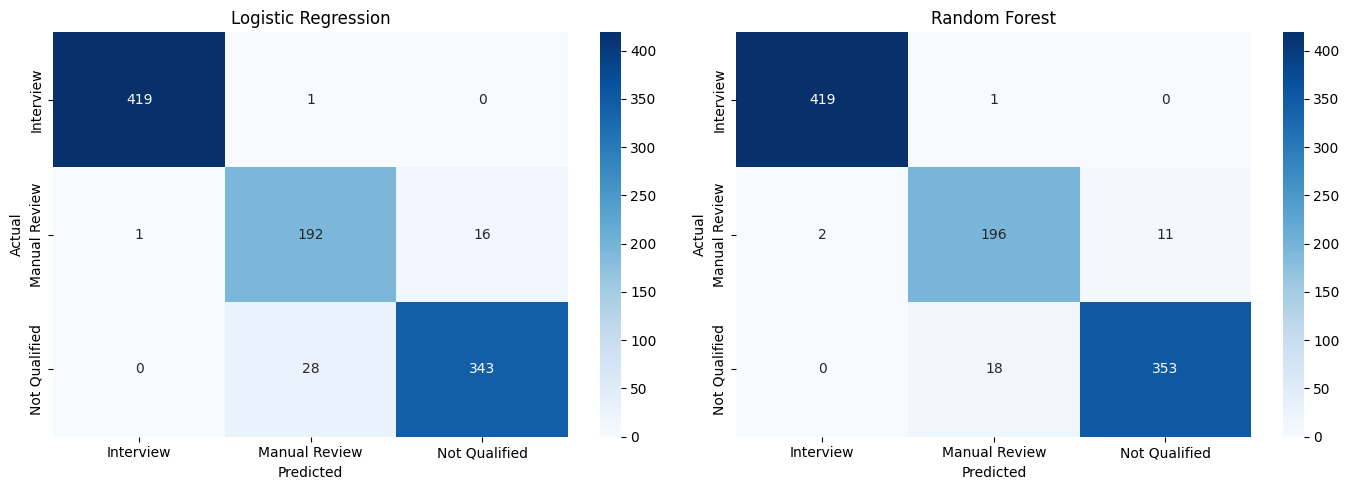

In [30]:
# Confusion Matrix

labels = ['Interview', 'Manual Review', 'Not Qualified']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_val, log_reg_val_preds, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_val, rf_val_preds, labels=labels)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

The diagonal cells are correct predictions; off-diagonal cells show what's being confused with what. Look especially at whether "Interview" candidates are being wrongly predicted as "Not Qualified" (a costly mistake — losing good candidates).

In [31]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(10)

my_required_coverage      0.247721
num_required_missing      0.188669
num_required_matched      0.177269
my_preferred_coverage     0.095346
experience_gap            0.080985
experience_years          0.077929
text_similarity           0.050673
projects_count            0.030693
salary_expectation_usd    0.009906
salary_gap                0.009359
dtype: float64

This tells you which features actually drove the model's decisions. The model is not just guessing, it's using the exact signals a human recruiter would have looked at.

These are strong, sensible results and importantly, they tell a coherent story.

What this means:

- Random Forest wins (96.8% vs 95.4% accuracy and better F1 on the harder "Manual Review" class — 0.92 vs 0.89). It will be the model of choice going forward.

- "Interview" is predicted perfectly (1.00/1.00) by both models which makes sense, since strong matches on required skills are the clearest signal.

- "Manual Review" is the hardest class for both (lowest F1) which is expected and actually reassuring: it's the genuinely ambiguous middle ground, exactly the cases where a human should be reviewing anyway.

- Feature importance confirms the model learned what a recruiter would care about: my_required_coverage, num_required_missing, and num_required_matched dominate (the hand-built skill-overlap features), followed by experience_gap/experience_years. Notably, text_similarity (the TF-IDF/cosine feature) matters but ranks lower which is a good, honest thing to discuss: structured skill-matching turned out more predictive than free-text similarity here, which is a real, defensible finding, not a flaw.

Final Test Check below

In [32]:
rf_test_preds = rf.predict(X_test)

print("=== Random Forest — TEST SET (final) ===")
print("Accuracy:", accuracy_score(y_test, rf_test_preds))
print(classification_report(y_test, rf_test_preds))

=== Random Forest — TEST SET (final) ===
Accuracy: 0.965
               precision    recall  f1-score   support

    Interview       0.99      1.00      0.99       823
Manual Review       0.92      0.91      0.91       407
Not Qualified       0.96      0.96      0.96       770

     accuracy                           0.96      2000
    macro avg       0.96      0.96      0.96      2000
 weighted avg       0.96      0.96      0.96      2000



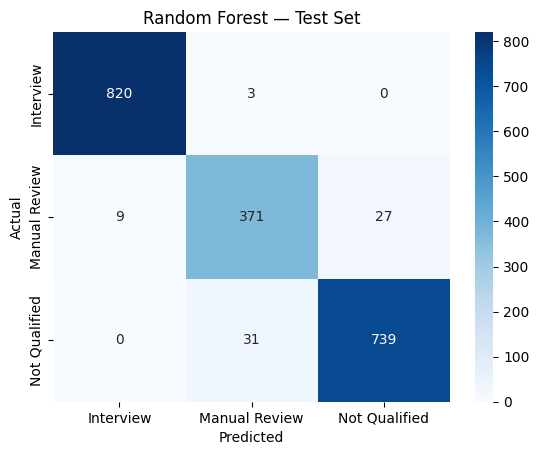

In [33]:
cm_test = confusion_matrix(y_test, rf_test_preds, labels=labels)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Random Forest — Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# PREDICTION FUNCTION

Making the trained model into something that takes a new, raw CV + job description and produces the human-readable output.

In [34]:
def match_candidate(candidate_skills_str, candidate_experience_years, candidate_projects_count,
                     candidate_education, candidate_work_auth, candidate_salary_expectation,
                     resume_summary_text,
                     required_skills_str, preferred_skills_str, min_experience_years,
                     salary_min, salary_max, job_description_text):
    
    # --- 1. Clean & structure inputs the same way as training data ---
    cand_skills = skills_to_list(candidate_skills_str)
    req_skills = skills_to_list(required_skills_str)
    pref_skills = skills_to_list(preferred_skills_str)
    
    resume_clean = clean_text(resume_summary_text)
    job_clean = clean_text(job_description_text)
    
    degree_lvl = get_degree_level(candidate_education)
    field = re.sub(r'^(B\.Sc|B\.Eng|M\.Sc|PhD)\s+', '', candidate_education)
    work_auth_encoded = 1 if candidate_work_auth == 'Authorized' else 0
    
    # --- 2. Skill overlap features (same logic as training) ---
    skill_feats = skill_overlap_features(cand_skills, req_skills, pref_skills)
    
    # --- 3. Text similarity using the SAME fitted vectorizer ---
    resume_vec = vectorizer.transform([resume_clean])
    job_vec = vectorizer.transform([job_clean])
    text_sim = cosine_similarity(resume_vec, job_vec)[0][0]
    
    # --- 4. Numeric gap features ---
    exp_gap = candidate_experience_years - min_experience_years
    sal_gap = candidate_salary_expectation - salary_max
    
    # --- 5. Assemble feature row matching training column order ---
    row = {
        'experience_years': candidate_experience_years,
        'projects_count': candidate_projects_count,
        'salary_expectation_usd': candidate_salary_expectation,
        'minimum_experience_years': min_experience_years,
        'salary_min_usd': salary_min,
        'salary_max_usd': salary_max,
        'degree_level': degree_lvl,
        'work_authorization_encoded': work_auth_encoded,
        'my_required_coverage': skill_feats['my_required_coverage'],
        'my_preferred_coverage': skill_feats['my_preferred_coverage'],
        'num_required_matched': skill_feats['num_required_matched'],
        'num_required_missing': skill_feats['num_required_missing'],
        'num_extra_skills': skill_feats['num_extra_skills'],
        'text_similarity': text_sim,
        'experience_gap': exp_gap,
        'salary_gap': sal_gap,
    }
    
    # one-hot field columns - set all to 0, then set the matching one to 1 if it exists
    for col in field_cols:
        row[col] = 1 if col == f'field_{field}' else 0
    
    X_new = pd.DataFrame([row])[feature_cols]  # enforce same column order as training
    
    # --- 6. Predict ---
    prediction = rf.predict(X_new)[0]
    probabilities = rf.predict_proba(X_new)[0]
    prob_dict = dict(zip(rf.classes_, probabilities))
    confidence = max(probabilities) * 100
    
    # --- 7. Build human-readable output ---
    matched_required = set(cand_skills) & set(req_skills)
    missing_required = set(req_skills) - set(cand_skills)
    
    print("="*50)
    print("AI CV SCREENING SYSTEM")
    print("="*50)
    print(f"Candidate Match Confidence: {confidence:.0f}%")
    print(f"Recommendation: {prediction.upper()}")
    print()
    print("Matched Required Skills:")
    for s in matched_required:
        print(f"  ✓ {s}")
    print()
    if missing_required:
        print("Missing Required Skills:")
        for s in missing_required:
            print(f"  ✗ {s}")
    else:
        print("Missing Required Skills: None")
    print()
    exp_relevance = "HIGH" if exp_gap >= 0 else ("MEDIUM" if exp_gap >= -2 else "LOW")
    print(f"Experience Relevance: {exp_relevance}")
    print()
    print("Class Probabilities:")
    for cls, prob in prob_dict.items():
        print(f"  {cls}: {prob*100:.1f}%")
    print("="*50)
    print("NOTE: This is an assistive recommendation only.")
    print("Final hiring decisions should always involve human review.")
    
    return prediction, prob_dict

In [ ]:
match_candidate(
    candidate_skills_str="Python, Django, PostgreSQL, Git, JavaScript, React",
    candidate_experience_years=3,
    candidate_projects_count=4,
    candidate_education="B.Sc Computer Science",
    candidate_work_auth="Authorized",
    candidate_salary_expectation=90000,
    resume_summary_text="Experienced backend developer skilled in Python and Django, with growing frontend experience in React.",
    required_skills_str="Python, Django, REST API, PostgreSQL, Git, React",
    preferred_skills_str="Docker, AWS",
    min_experience_years=2,
    salary_min=70000,
    salary_max=110000,
    job_description_text="We are looking for a backend developer with strong Python and Django experience, PostgreSQL, Git, and React knowledge, building REST APIs."
)

AI CV SCREENING SYSTEM
Candidate Match Confidence: 90%
Recommendation: MANUAL REVIEW

Matched Required Skills:
  ✓ postgresql
  ✓ python
  ✓ git
  ✓ django
  ✓ react

Missing Required Skills:
  ✗ rest api

Experience Relevance: HIGH

Class Probabilities:
  Interview: 7.1%
  Manual Review: 90.4%
  Not Qualified: 2.6%
NOTE: This is an assistive recommendation only.
Final hiring decisions should always involve human review.


('Manual Review',
 {'Interview': np.float64(0.07059580349892983),
  'Manual Review': np.float64(0.903519431113466),
  'Not Qualified': np.float64(0.025884765387604237)})

# SIMPLE INTERFACE

In [36]:
import joblib

joblib.dump(rf, 'cv_screening_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
joblib.dump(field_cols, 'field_cols.pkl')

print("Model artifacts saved.")

Model artifacts saved.
